# Contrast check: RF-on vs. RF-off at 2.87 GHz

Plots `python cw_odmr.py contrast_check` results (`contrast1`, `contrast2`) --
direct RF-on vs. RF-off comparison at a single fixed frequency with many more
segments than a `run_spectrum` point gets, meant to settle whether a real ODMR
contrast exists above the noise/drift floor. `contrast1` used the original
long-RF-on-then-long-RF-off design (~5 min apart); `contrast2` used the later
alternating-block design (100-segment blocks interleaved throughout the run) --
kept separate here since they're not quite the same acquisition strategy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

DATA_DIR = "D:/cw_odmr"
NAMES = ["contrast1", "contrast2"]

## Load and compare

In [2]:
def load_contrast(name):
    on = np.load(f"{DATA_DIR}/{name}/{name}.npy")
    off = np.load(f"{DATA_DIR}/{name}/{name}_bg.npy")
    on_seg_mean = on.mean(axis=1)
    off_seg_mean = off.mean(axis=1)
    on_avg = on_seg_mean.mean()
    on_sem = on_seg_mean.std() / np.sqrt(len(on_seg_mean))
    off_avg = off_seg_mean.mean()
    off_sem = off_seg_mean.std() / np.sqrt(len(off_seg_mean))
    net = on_avg - off_avg
    net_sem = np.sqrt(on_sem**2 + off_sem**2)
    t_stat, p_val = ttest_ind(on_seg_mean, off_seg_mean)
    return {
        "name": name, "on_seg_mean": on_seg_mean, "off_seg_mean": off_seg_mean,
        "on_avg": on_avg, "on_sem": on_sem, "off_avg": off_avg, "off_sem": off_sem,
        "net": net, "net_sem": net_sem, "t_stat": t_stat, "p_val": p_val,
    }


results = [load_contrast(name) for name in NAMES]
for r in results:
    n_sigma = abs(r["net"]) / r["net_sem"] if r["net_sem"] > 0 else float("inf")
    print(f"{r['name']}: RF-on {r['on_avg']:.6f} +/- {r['on_sem']:.6f} V, "
          f"RF-off {r['off_avg']:.6f} +/- {r['off_sem']:.6f} V")
    print(f"  net (on - off) = {r['net']:+.6f} +/- {r['net_sem']:.6f} V "
          f"({n_sigma:.1f} sigma), t-test p = {r['p_val']:.2e}")

contrast1: RF-on -0.011215 +/- 0.000036 V, RF-off -0.010941 +/- 0.000034 V
  net (on - off) = -0.000274 +/- 0.000050 V (5.5 sigma), t-test p = 3.25e-08
contrast2: RF-on -0.010930 +/- 0.000038 V, RF-off -0.010534 +/- 0.000038 V
  net (on - off) = -0.000396 +/- 0.000054 V (7.3 sigma), t-test p = 3.80e-13


## Segment-value distributions

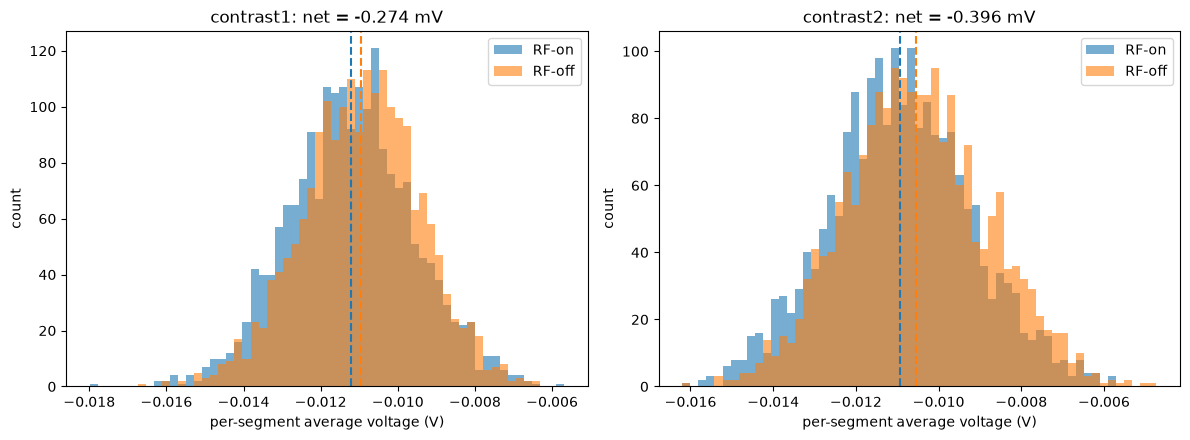

In [3]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, r in zip(axes, results):
    bins = np.linspace(
        min(r["on_seg_mean"].min(), r["off_seg_mean"].min()),
        max(r["on_seg_mean"].max(), r["off_seg_mean"].max()), 60,
    )
    ax.hist(r["on_seg_mean"], bins=bins, alpha=0.6, label="RF-on", color="C0")
    ax.hist(r["off_seg_mean"], bins=bins, alpha=0.6, label="RF-off", color="C1")
    ax.axvline(r["on_avg"], color="C0", ls="--")
    ax.axvline(r["off_avg"], color="C1", ls="--")
    ax.set_xlabel("per-segment average voltage (V)")
    ax.set_ylabel("count")
    ax.set_title(f"{r['name']}: net = {r['net']*1e3:+.3f} mV")
    ax.legend()
plt.tight_layout()
plt.show()

## Interpretation caveat: the sign is backwards for a real ODMR effect

Both runs show a real, statistically significant, and reproducible difference
(5.5 sigma for `contrast1`, 7.3 sigma for `contrast2`, both p << 0.001) -- so this
isn't noise. But in both, **RF-on is MORE negative than RF-off**, i.e. RF-on reads as
*more* fluorescence given this PMT's established sign convention (more light = more
negative voltage). A real ODMR resonance does the opposite: driving the MW pumps
population from the bright ms=0 state into the dark ms=+-1 states, so RF-on at
resonance should REDUCE fluorescence (less negative voltage), not increase it.

That mismatch points toward this being an electrical/RF-pickup artifact -- the
microwave drive directly coupling into the PMT/scope signal path when switched on
(EMI, ground loop, cable proximity), rather than a genuine optical fluorescence
change from spin population transfer. Two concrete ways to tell them apart:

1. **Block the optical path to the PMT** (cover the detector, or block the laser)
   and repeat the RF-on/RF-off comparison. If the same-sized shift persists with no
   light reaching the PMT at all, it's definitively electrical pickup.
2. **Move the frequency far from any expected NV resonance** (e.g. 2.5 or 3.2 GHz)
   and repeat. A real spin-resonance effect should vanish or shrink well away from
   resonance; a fixed-size shift regardless of frequency points at pickup instead.

Worth noting for scale: the effect is small in absolute terms (0.27-0.40 mV against
an ~11 mV baseline, ~2.5-3.6%) -- a plausible size for real ODMR contrast, which is
part of why the sign mismatch is the more informative clue here than the magnitude.